__**CNN Fault Detection (PyTorch with GPU)**__

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, classification_report

# device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print device
print(f'Using device: {device}')


Using device: cuda


__Load Dataset__

In [6]:
data = pd.read_csv('Line_fault_dataset.csv')
data.head()

,Va_rms,Vb_rms,Vc_rms,Ia_rms,Ib_rms,Ic_rms,Va_mag,Va_ang,Ra,Xa,...,Xb,Vc_mag,Vc_ang,Rc,Xc,RFault,A,B,C,G
0,6552.899826,6804.930627,6619.901213,0.006553,0.006805,0.006620,9267.199807,-1.601324,1000000.003,-0.108540,...,0.052530,9361.954077,0.554074,999999.9089,0.057041,0.001,0,0,0,0
1,6549.896200,6809.237388,6619.439383,0.006550,0.006809,0.006619,9262.952039,-1.601789,1000000.003,-0.108602,...,0.052490,9361.300951,0.554551,999999.9089,0.057105,0.001,0,0,0,0
2,6550.371863,6809.029053,6619.763243,0.006550,0.006809,0.006620,9263.624727,-1.601901,1000000.003,-0.108594,...,0.052496,9361.758957,0.554595,999999.9089,0.057107,0.001,0,0,0,0
3,6550.218464,6809.491844,6617.394464,0.006550,0.006809,0.006617,9263.407788,-1.601798,1000000.003,-0.108600,...,0.052485,9358.408998,0.554559,999999.9089,0.057123,0.001,0,0,0,0
4,6550.492756,6808.427547,6618.855299,0.006550,0.006808,0.006619,9263.795696,-1.601737,1000000.003,-0.108591,...,0.052496,9360.474931,0.554509,999999.9089,0.057104,0.001,0,0,0,0


__Preprocess Dataset__

In [7]:
# ADD differential features
data['dVa_rms'] = data['Va_rms'].diff().fillna(0)
data['dVb_rms'] = data['Vb_rms'].diff().fillna(0)
data['dVc_rms'] = data['Vc_rms'].diff().fillna(0)
data['dIa_rms'] = data['Ia_rms'].diff().fillna(0)
data['dIb_rms'] = data['Ib_rms'].diff().fillna(0)
data['dIc_rms'] = data['Ic_rms'].diff().fillna(0)

# ADD power features
data['Pa'] = data['Va_rms'] * data['Ia_rms']
data['Pb'] = data['Vb_rms'] * data['Ib_rms']
data['Pc'] = data['Vc_rms'] * data['Ic_rms']

# Create fault type label based on A, B, C, G columns
def get_fault_type(row):
    faults = []
    if row['A']: faults.append('A')
    if row['B']: faults.append('B')
    if row['C']: faults.append('C')
    if row['G']: faults.append('G')
    return 'Normal' if not faults else ''.join(faults)

data['Fault_Type'] = data.apply(get_fault_type, axis=1)

# Drop fault resistance due to low varience
if 'RFault' in data.columns:
    data = data.drop(columns=['RFault'])

data = data.drop(columns=['A', 'B', 'C', 'G'])

le = LabelEncoder()
y = le.fit_transform(data['Fault_Type'])
X = data.drop(columns=['Fault_Type']).values

# Print different types of faults
fault_classes = le.classes_
num_classes = len(fault_classes)
print(f'Classes: {fault_classes}')
print(f'Number of classes: {num_classes}')

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f'Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}')

Classes: ['AB' 'ABC' 'ABCG' 'AC' 'AG' 'BC' 'BG' 'CG' 'Normal']
Number of classes: 9
Training samples: 921, Test samples: 231


__Define Conv1D Model__

In [8]:
class Conv1DFaultClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(Conv1DFaultClassifier, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv1(x)
        x = self.conv2(x)
        x = torch.max(x, dim=2)[0]
        x = self.fc(x)
        return x


model = Conv1DFaultClassifier(1, num_classes).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters())}')

Conv1DFaultClassifier(
  (conv1): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=9, bias=True)
  )
)

Total parameters: 33801


__Train Model__

In [12]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5000
best_train_acc = 0
best_test_acc = 0

for epoch in range(epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 500 == 0:
        model.eval()
        with torch.no_grad():
            train_outputs = model(X_train_tensor)
            test_outputs = model(X_test_tensor)
            train_preds = torch.argmax(train_outputs, dim=1)
            test_preds = torch.argmax(test_outputs, dim=1)
            train_acc = accuracy_score(y_train, train_preds.cpu().numpy())
            test_acc = accuracy_score(y_test, test_preds.cpu().numpy())
        print(f'Epoch {epoch+1}/{epochs}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_train_acc = train_acc
            torch.save(model.state_dict(), 'best_model.pth')

model.load_state_dict(torch.load('best_model.pth', weights_only=True))
print(f'\nFinal - Train Accuracy: {best_train_acc:.4f}, Test Accuracy: {best_test_acc:.4f}')

Epoch 500/5000, Train Acc: 0.9783, Test Acc: 0.9567
Epoch 1000/5000, Train Acc: 0.9870, Test Acc: 0.9697
Epoch 1500/5000, Train Acc: 0.9870, Test Acc: 0.9654
Epoch 2000/5000, Train Acc: 0.9815, Test Acc: 0.9697
Epoch 2500/5000, Train Acc: 0.9881, Test Acc: 0.9524
Epoch 3000/5000, Train Acc: 0.9881, Test Acc: 0.9567
Epoch 3500/5000, Train Acc: 0.9859, Test Acc: 0.9524
Epoch 4000/5000, Train Acc: 0.9881, Test Acc: 0.9524
Epoch 4500/5000, Train Acc: 0.9870, Test Acc: 0.9481
Epoch 5000/5000, Train Acc: 0.9881, Test Acc: 0.9524

Final - Train Accuracy: 0.9870, Test Accuracy: 0.9697


__Model Metrics__

CNN Accuracy - Training: 0.9870, Test: 0.9697
CNN Precision - Training: 0.9893, Test: 0.9725


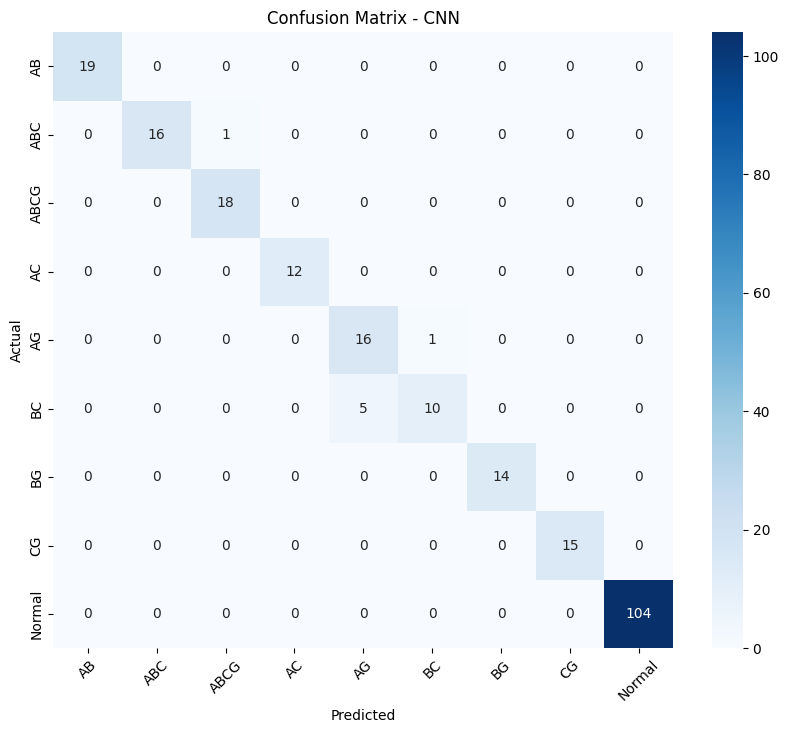


Classification Report:
              precision    recall  f1-score   support

          AB       1.00      1.00      1.00        19
         ABC       1.00      0.94      0.97        17
        ABCG       0.95      1.00      0.97        18
          AC       1.00      1.00      1.00        12
          AG       0.76      0.94      0.84        17
          BC       0.91      0.67      0.77        15
          BG       1.00      1.00      1.00        14
          CG       1.00      1.00      1.00        15
      Normal       1.00      1.00      1.00       104

    accuracy                           0.97       231
   macro avg       0.96      0.95      0.95       231
weighted avg       0.97      0.97      0.97       231



In [13]:
model.eval()
with torch.no_grad():
    train_outputs = model(X_train_tensor)
    test_outputs = model(X_test_tensor)
    train_preds = torch.argmax(train_outputs, dim=1).cpu().numpy()
    test_preds = torch.argmax(test_outputs, dim=1).cpu().numpy()

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)
train_prec = precision_score(y_train, train_preds, average='weighted', zero_division=0)
test_prec = precision_score(y_test, test_preds, average='weighted', zero_division=0)

print(f'CNN Accuracy - Training: {train_acc:.4f}, Test: {test_acc:.4f}')
print(f'CNN Precision - Training: {train_prec:.4f}, Test: {test_prec:.4f}')

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=fault_classes, yticklabels=fault_classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CNN')
plt.xticks(rotation=45)
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, test_preds, target_names=fault_classes))